# 🎭 Professional Facial Emotion Training (EfficientNet-V2-S)

**Backend:** EfficientNet-V2-S  
**Dataset:** Roboflow  
**Features:** Phase-based Training, Class Distribution, Confusion Matrix, Visualization

This notebook implements a professional two-phase fine-tuning strategy for facial emotion classification.

In [1]:
%%capture
# --- 1. Environment Setup ---
!pip install -q roboflow tqdm matplotlib seaborn scikit-learn

In [2]:
import os
import time
import copy
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from PIL import Image
from roboflow import Roboflow
from sklearn.metrics import confusion_matrix, classification_report

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models

# Device Configuration
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Executing on: {device}")

Executing on: cuda


In [ ]:
# --- 2. Download Roboflow Dataset ---
ROBOFLOW_API_KEY = os.getenv("ROBOFLOW_API_KEY", "Your_Roboflow_API_Key_Here")
ROBOFLOW_WORKSPACE = os.getenv("ROBOFLOW_WORKSPACE", "Your_Roboflow_Workspace_Here")
ROBOFLOW_PROJECT = os.getenv("ROBOFLOW_PROJECT", "Your_Roboflow_Project_Here")
ROBOFLOW_VERSION = int(os.getenv("ROBOFLOW_VERSION", "1"))
EXPORT_FORMAT = "folder" 

print("⏳ Fetching dataset...")
rf = Roboflow(api_key=ROBOFLOW_API_KEY)
project = rf.workspace(ROBOFLOW_WORKSPACE).project(ROBOFLOW_PROJECT)
rf_dataset = project.version(ROBOFLOW_VERSION).download(EXPORT_FORMAT)
base_dir = rf_dataset.location

train_dir = os.path.join(base_dir, "train")
val_dir = os.path.join(base_dir, "valid")
test_dir = os.path.join(base_dir, "test") if os.path.exists(os.path.join(base_dir, "test")) else val_dir

⏳ Fetching dataset...
loading Roboflow workspace...
loading Roboflow project...
Exporting format folder in progress : 85.0%
Version export complete for folder format



Extracting Dataset Version Zip to Face-emotion-classification--1 in folder:: 100%|██████████| 1295/1295 [00:00<00:00, 12265.02it/s]


📊 Analyzing data distribution...




Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.



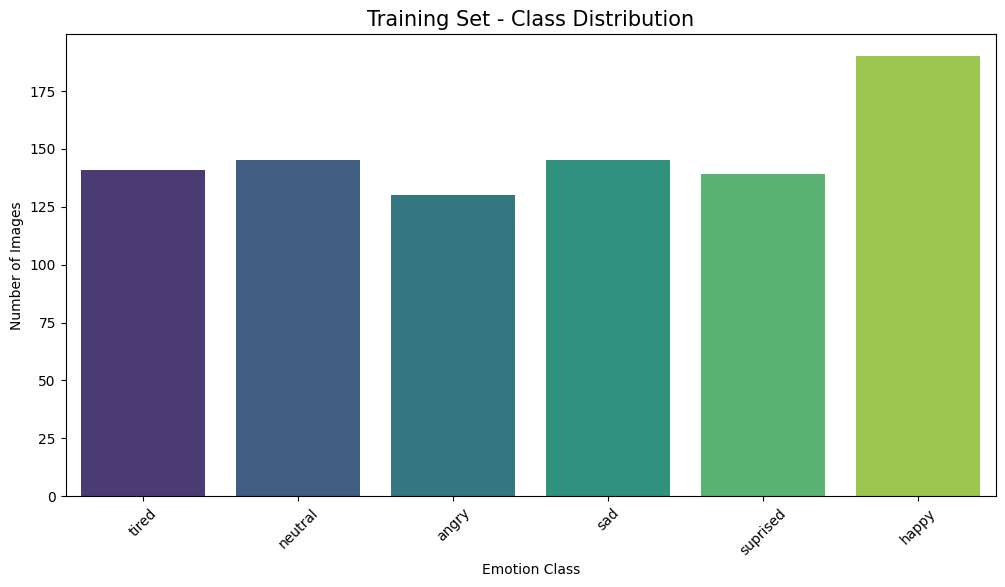

In [5]:
# --- 3. Training Set — Class Distribution ---
def plot_distribution(data_dir):
    classes = os.listdir(data_dir)
    counts = {c: len(os.listdir(os.path.join(data_dir, c))) for c in classes if os.path.isdir(os.path.join(data_dir, c))}
    
    plt.figure(figsize=(12, 6))
    sns.barplot(x=list(counts.keys()), y=list(counts.values()), palette="viridis")
    plt.title("Training Set - Class Distribution", fontsize=15)
    plt.xlabel("Emotion Class")
    plt.ylabel("Number of Images")
    plt.xticks(rotation=45)
    plt.show()
    return counts

print("📊 Analyzing data distribution...")
dist = plot_distribution(train_dir)

In [6]:
# --- 4. Data Preparation ---
IMAGE_SIZE = 224 
BATCH_SIZE = 32

data_transforms = {
    'train': transforms.Compose([
        transforms.RandomResizedCrop(IMAGE_SIZE),
        transforms.RandomHorizontalFlip(),
        transforms.RandomRotation(15),
        transforms.ColorJitter(brightness=0.2, contrast=0.2),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'val': transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(IMAGE_SIZE),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}

image_datasets = {
    'train': datasets.ImageFolder(train_dir, data_transforms['train']),
    'val': datasets.ImageFolder(val_dir, data_transforms['val'])
}

dataloaders = {
    'train': DataLoader(image_datasets['train'], batch_size=BATCH_SIZE, shuffle=True, num_workers=2),
    'val': DataLoader(image_datasets['val'], batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
}

class_names = image_datasets['train'].classes
num_classes = len(class_names)
print(f"Ready to train with {num_classes} classes: {class_names}")

Ready to train with 6 classes: ['angry', 'happy', 'neutral', 'sad', 'suprised', 'tired']


In [7]:
# --- 5. Model Initialization ---
def create_model(num_classes):
    model = models.efficientnet_v2_s(weights=models.EfficientNet_V2_S_Weights.DEFAULT)
    num_ftrs = model.classifier[1].in_features
    
    # Custom Head
    model.classifier[1] = nn.Sequential(
        nn.Linear(num_ftrs, 128),
        nn.ReLU(),
        nn.Dropout(p=0.3),
        nn.Linear(128, num_classes)
    )
    return model.to(device)

model = create_model(num_classes)

Downloading: "https://download.pytorch.org/models/efficientnet_v2_s-dd5fe13b.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_v2_s-dd5fe13b.pth


100%|██████████| 82.7M/82.7M [00:00<00:00, 192MB/s] 


In [8]:
# --- 6. Training Engine ---
def run_training(model, criterion, optimizer, scheduler, num_epochs=10):
    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
    best_model_wts = copy.deepcopy(model.state_dict())
    best_acc = 0.0

    for epoch in range(num_epochs):
        print(f'Epoch {epoch + 1}/{num_epochs}')
        print('-' * 10)

        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()
            else:
                model.eval()

            running_loss = 0.0
            running_corrects = 0

            for inputs, labels in tqdm(dataloaders[phase], desc=phase):
                inputs, labels = inputs.to(device), labels.to(device)
                optimizer.zero_grad()

                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)

                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)

            epoch_loss = running_loss / len(image_datasets[phase])
            epoch_acc = running_corrects.double() / len(image_datasets[phase])

            print(f'{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')
            
            history[f'{phase}_loss'].append(epoch_loss)
            history[f'{phase}_acc'].append(epoch_acc.cpu().item())

            if phase == 'val' and epoch_acc > best_acc:
                best_acc = epoch_acc
                best_model_wts = copy.deepcopy(model.state_dict())
        
        if scheduler: scheduler.step()
        print()

    print(f'Validation Best Acc: {best_acc:4f}')
    model.load_state_dict(best_model_wts)
    return model, history

### Phase 1: Training the Classifier Head
In this phase, we freeze the EfficientNet backbone and only train our custom top layers. This prevents large gradients from destroying pre-trained ImageNet features.

In [9]:
print("🚀 Phase 1: Training Classifier Head...")
for param in model.features.parameters():
    param.requires_grad = False

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.classifier.parameters(), lr=1e-3)
model, history_p1 = run_training(model, criterion, optimizer, None, num_epochs=5)

🚀 Phase 1: Training Classifier Head...
Epoch 1/5
----------


train: 100%|██████████| 28/28 [00:04<00:00,  6.32it/s]


train Loss: 1.7453 Acc: 0.2461


val: 100%|██████████| 8/8 [00:00<00:00,  8.35it/s]


val Loss: 1.6634 Acc: 0.4118

Epoch 2/5
----------


...

val Loss: 1.3436 Acc: 0.5451

Epoch 5/5
----------


train: 100%|██████████| 28/28 [00:03<00:00,  8.69it/s]


train Loss: 1.3195 Acc: 0.5191


val: 100%|██████████| 8/8 [00:00<00:00,  8.49it/s]

val Loss: 1.3108 Acc: 0.5373

Validation Best Acc: 0.545098


### Phase 2: Full Model Fine-Tuning
Now we unfreeze the entire model and train with a very small learning rate to adapt the backbone features to facial emotions.

In [15]:
print("🔥 Phase 2: Fine-tuning Full Model...")
for param in model.parameters():
    param.requires_grad = True

optimizer = optim.Adam(model.parameters(), lr=1e-5)
model, history_p2 = run_training(model, criterion, optimizer, None, num_epochs=50)

🔥 Phase 2: Fine-tuning Full Model...
Epoch 1/50
----------


train: 100%|██████████| 28/28 [00:09<00:00,  2.84it/s]


train Loss: 0.8383 Acc: 0.7056


val: 100%|██████████| 8/8 [00:01<00:00,  8.00it/s]


val Loss: 0.4838 Acc: 0.8667

Epoch 2/50
----------


...

val Loss: 0.0995 Acc: 0.9725

Epoch 50/50
----------


train: 100%|██████████| 28/28 [00:11<00:00,  2.43it/s]


train Loss: 0.2387 Acc: 0.9213


val: 100%|██████████| 8/8 [00:01<00:00,  7.17it/s]

val Loss: 0.1106 Acc: 0.9647

Validation Best Acc: 0.972549


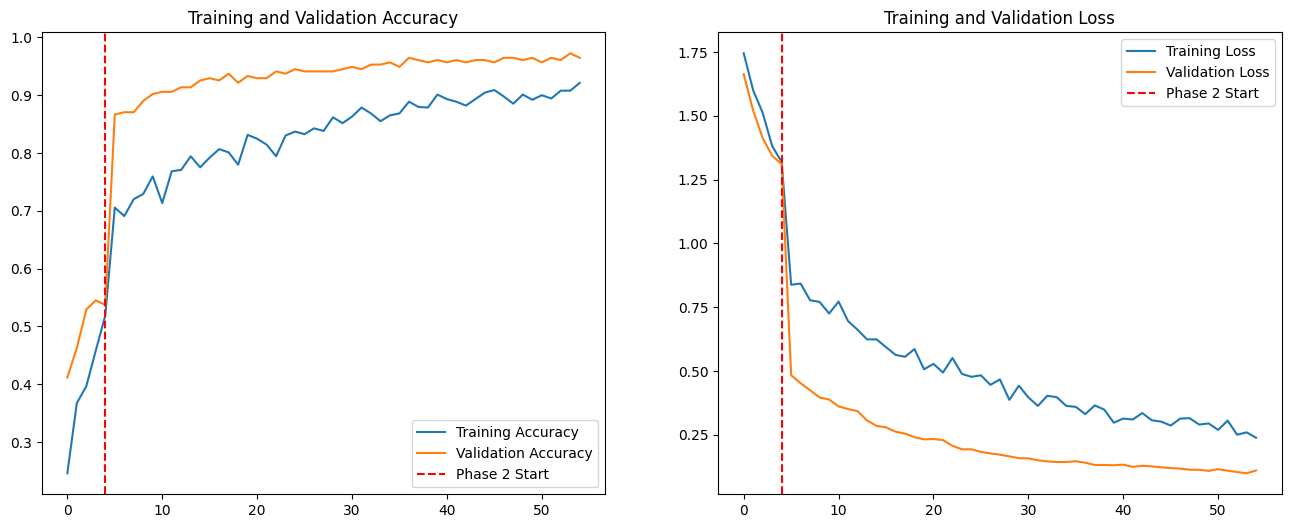

In [16]:
# --- 7. Plotting Training Progress ---
def plot_history(h1, h2):
    # Merge histories
    acc = h1['train_acc'] + h2['train_acc']
    val_acc = h1['val_acc'] + h2['val_acc']
    loss = h1['train_loss'] + h2['train_loss']
    val_loss = h1['val_loss'] + h2['val_loss']
    
    epochs_range = range(len(acc))

    plt.figure(figsize=(16, 6))
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Training Accuracy')
    plt.plot(epochs_range, val_acc, label='Validation Accuracy')
    plt.axvline(x=len(h1['train_acc'])-1, color='r', linestyle='--', label='Phase 2 Start')
    plt.legend(loc='lower right')
    plt.title('Training and Validation Accuracy')

    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Training Loss')
    plt.plot(epochs_range, val_loss, label='Validation Loss')
    plt.axvline(x=len(h1['train_loss'])-1, color='r', linestyle='--', label='Phase 2 Start')
    plt.legend(loc='upper right')
    plt.title('Training and Validation Loss')
    plt.show()

plot_history(history_p1, history_p2)

📈 Generating Confusion Matrix...


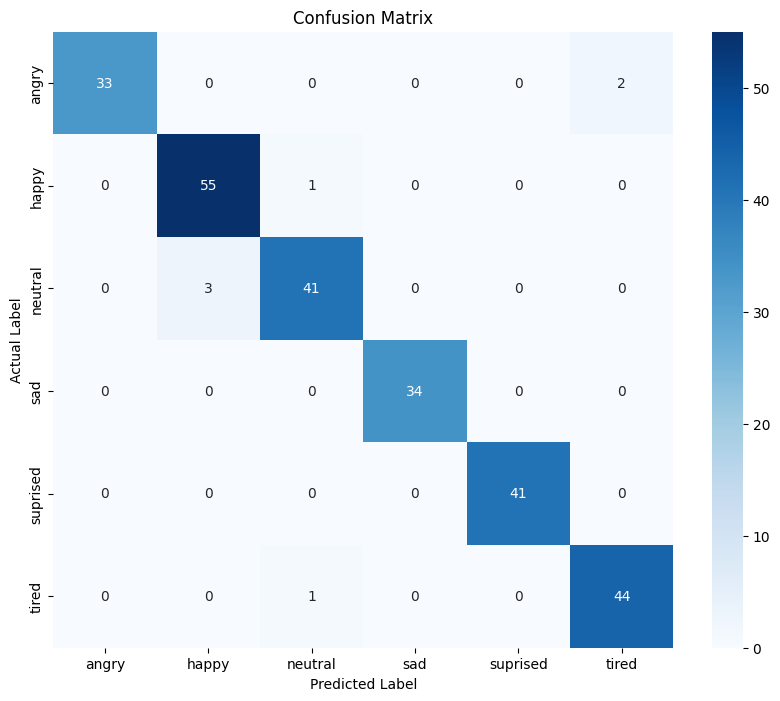

              precision    recall  f1-score   support

       angry       1.00      0.94      0.97        35
       happy       0.95      0.98      0.96        56
     neutral       0.95      0.93      0.94        44
         sad       1.00      1.00      1.00        34
    suprised       1.00      1.00      1.00        41
       tired       0.96      0.98      0.97        45

    accuracy                           0.97       255
   macro avg       0.98      0.97      0.97       255
weighted avg       0.97      0.97      0.97       255



In [17]:
# --- 8. Confusion Matrix ---
def plot_confusion_matrix(model, dataloader):
    model.eval()
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs = inputs.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            
    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
    plt.title('Confusion Matrix')
    plt.ylabel('Actual Label')
    plt.xlabel('Predicted Label')
    plt.show()
    
    print(classification_report(all_labels, all_preds, target_names=class_names))

print("📈 Generating Confusion Matrix...")
plot_confusion_matrix(model, dataloaders['val'])

🎼 Visualizing Random Predictions...


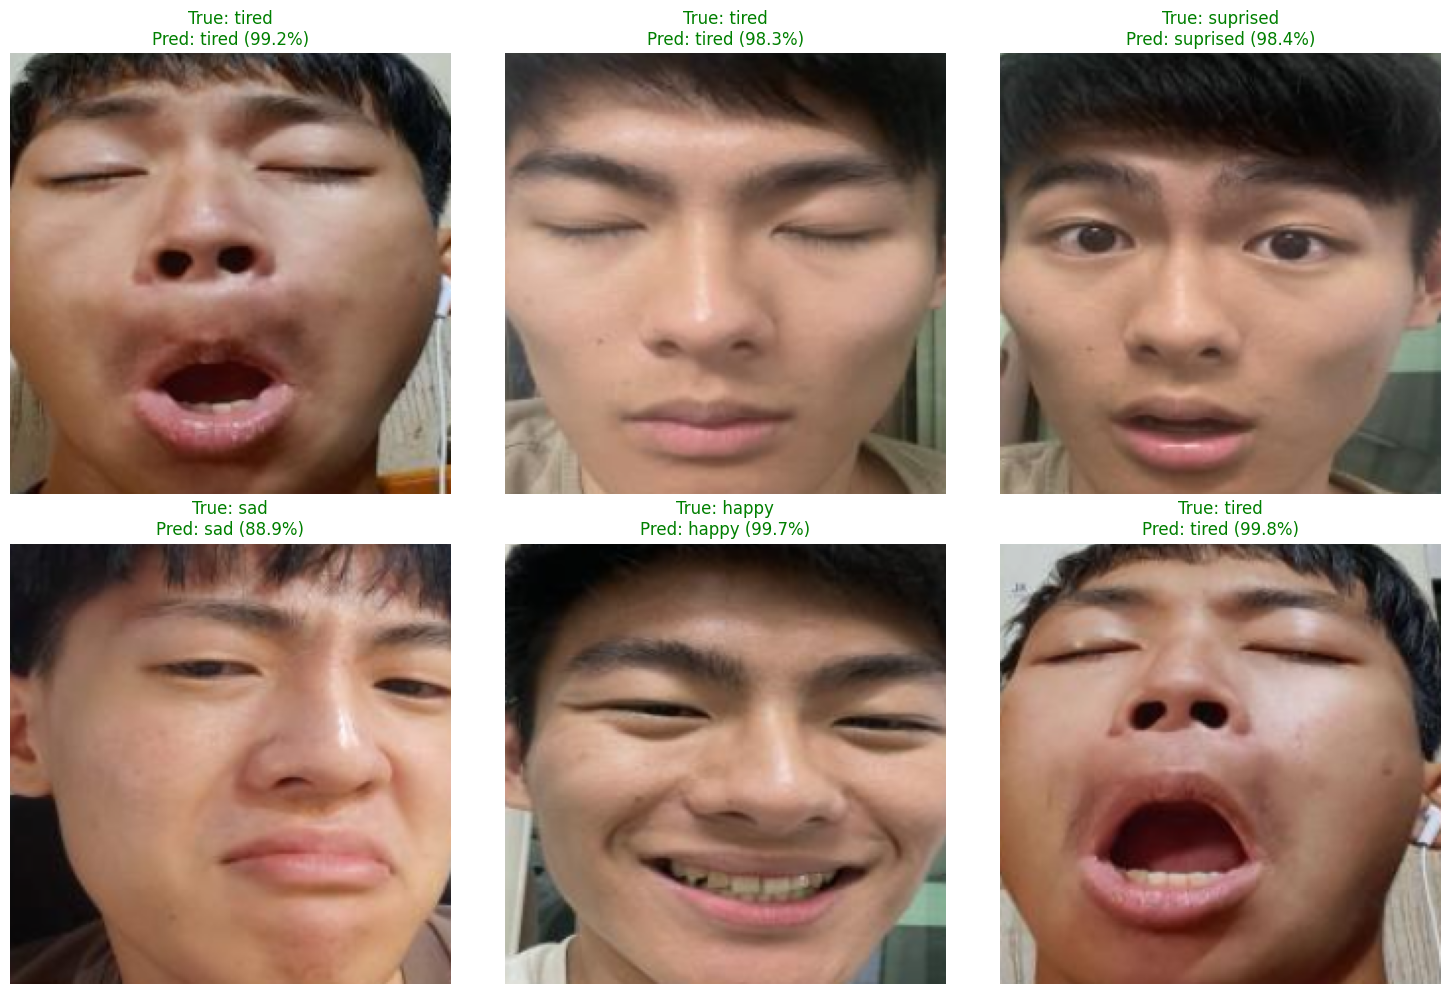

In [22]:
# --- 9. Random Predictions with Confidence ---
def display_predictions(model, dataset, num_images=6):
    model.eval()
    plt.figure(figsize=(15, 10))
    
    # Re-normalize for display
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    
    indices = np.random.choice(len(dataset), num_images, replace=False)
    
    for i, idx in enumerate(indices):
        img_tensor, label = dataset[idx]
        input_tensor = img_tensor.unsqueeze(0).to(device)
        
        with torch.no_grad():
            outputs = model(input_tensor)
            probs = torch.softmax(outputs, dim=1)
            conf, pred = torch.max(probs, 1)
            
        # Convert tensor to image
        img = img_tensor.permute(1, 2, 0).numpy()
        img = std * img + mean
        img = np.clip(img, 0, 1)
        
        plt.subplot(2, 3, i + 1)
        plt.imshow(img)
        color = 'green' if pred.item() == label else 'red'
        plt.title(f"True: {class_names[label]}\nPred: {class_names[pred.item()]} ({conf.item()*100:.1f}%)", color=color)
        plt.axis('off')
    
    plt.tight_layout()
    plt.show()

print("🎼 Visualizing Random Predictions...")
display_predictions(model, image_datasets['val'])

In [19]:
# --- 10. Save Final Weights ---
torch.save(model.state_dict(), 'best_emotion_model.pth')
print("Model saved as best_emotion_model.pth")

Model saved as best_emotion_model.pth
